In [1]:
# Allowing dynamic links, hot-reload, to our custom modules
%load_ext autoreload
%autoreload 2

In [2]:
import os, re, sys, traceback, csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

os.getcwd()

'C:\\Beryllium Base\\WORKSPACES\\MTECH\\dl-gen-lyrics\\sandbox'

In [3]:
import generator_core as core
from aspect_midnight import Word2Vec_SkipGram, ArrayToDatasetForW2V
from aspect_tetra import *
from aspect_cobalt import Cobalt

In [4]:
try:
    batch_count = 103
    genres = {'rap', 'rb', 'pop', 'country', 'rock', 'misc'}
    print(genres)
    print(batch_count)
except:
    traceback.print_exc()

{'rap', 'country', 'misc', 'rock', 'rb', 'pop'}
103


In [5]:
try:
    total_subset_size = 100000
    total_group_size = total_subset_size // len(genres) + 1
    max_songs_per_artist = 50
except:
    traceback.print_exc()

In [6]:
try:
    ds_subset = pd.read_csv(os.path.join('temp', 'genius_lyrics_subset.csv'))
    display(ds_subset.head())
except:
    traceback.print_exc()

,Unnamed: 0,title,tag,artist,year,lyrics,id,language
0,123725,In Memory of W. B. Yeats,misc,W. H. Auden,2013,I\n\nHe disappeared in the dead of winter:\nTh...,134446,en
1,2614099,Sthlm City,pop,Rebecca & Fiona,2018,"[Intro]\nI mean, like, it's okay\nOne day, you...",3931557,en
2,2550228,Fallin 2010,pop,Mozhdah,2010,[Verse 1]\nCan you take it easy\nWhile I make ...,3840000,en
3,3539706,Can the Circle Be Unbroken,country,Johnny Cash,1982,I was standing by the window\nOn one cold and ...,5350667,en
4,2650114,Marijuana,pop,Jah Cure,2019,[Intro: Jah Cure]\nOne puff one draw\nFrees th...,3982786,en


In [7]:
try:
    cobalt = Cobalt(ds_subset)
except:
    traceback.print_exc()

Loaded Cache for Midnight._prepare_ds_data.cached
Loaded Cache for Midnight._get_custom_tokens.cached
Loaded Cache for Midnight._get_genre_dict.cached
Loaded Cache for Midnight._prepare_tfidf.cached
Loaded Cache for Midnight._prepare_vocabulary temp\lyrics_sp.model
Loaded Cache for Midnight._prepare_embedder.cached


C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded Cache for Cobalt._prepare_training_data.cached
Loaded Cache for Cobalt._prepare_language_model.cached


In [8]:
try:
    print(cobalt.training_data.head())
except:
    traceback.print_exc()

0    [17, 2660, 68, 15, 2855, 26, 902, 16, 17, 1796...
1    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
2    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
3    [17, 2660, 68, 15, 7403, 297, 5743, 16, 17, 17...
4    [17, 2660, 68, 15, 1951, 1119, 16, 17, 1796, 1...
Name: tag, dtype: object


In [9]:
try:
    train_language_model = True
    print(cobalt.language_model)
except:
    traceback.print_exc()

BiGRULyricsModel(vocab=16000, embed=512, hidden=512, layers=2, params=8,419,456)


In [10]:
try:
    if train_language_model:

        cobalt.language_model.trainer.device = 'cuda'

        for pg in cobalt.language_model.trainer.optimizer.param_groups:
            # pg['lr'] = 0.0001
            print(pg['lr'])

        cobalt.language_model.embedding.weight.requires_grad = True
        print(cobalt.language_model.embedding.weight.requires_grad)

except:
    traceback.print_exc()

0.0003
True


In [11]:
try:
    if train_language_model:
        cobalt.language_model.trainer.train()
except:
    traceback.print_exc()

Epoch:  0/ 1    Train Loss: 8.85    TTS: 1.15    ETA: 7304.02
Epoch:  0/ 1    Train Loss: 6.88    TTS: 2.04    ETA: 5575.23
Epoch:  0/ 1    Train Loss: 5.16    TTS: 3.25    ETA: 5164.11
Epoch:  0/ 1    Train Loss: 4.83    TTS: 4.25    ETA: 5065.08
Epoch:  0/ 1    Train Loss: 4.48    TTS: 5.24    ETA: 4998.46
Epoch:  0/ 1    Train Loss: 4.34    TTS: 6.22    ETA: 4944.19
Epoch:  0/ 1    Train Loss: 4.11    TTS: 7.19    ETA: 4897.99
Epoch:  0/ 1    Train Loss: 3.96    TTS: 8.16    ETA: 4860.92
Epoch:  0/ 1    Train Loss: 4.02    TTS: 9.12    ETA: 4832.40
Epoch:  0/ 1    Train Loss: 3.78    TTS: 10.10    ETA: 4814.48
Epoch:  0/ 1    Train Loss: 3.70    TTS: 11.09    ETA: 4804.33
Epoch:  0/ 1    Train Loss: 3.66    TTS: 12.06    ETA: 4787.70
Epoch:  0/ 1    Train Loss: 3.43    TTS: 13.02    ETA: 4770.70
Epoch:  0/ 1    Train Loss: 3.41    TTS: 14.22    ETA: 4752.01
Epoch:  0/ 1    Train Loss: 3.42    TTS: 15.18    ETA: 4739.49
Epoch:  0/ 1    Train Loss: 3.35    TTS: 16.14    ETA: 4727.26
E

Traceback (most recent call last):
  File "C:\Users\mcxiv\AppData\Local\Temp\ipykernel_22224\170530448.py", line 3, in <module>
    cobalt.language_model.trainer.train()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 191, in train
    self._train_step(epoch)
    ~~~~~~~~~~~~~~~~^^^^^^^
  File "C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\src\dl_trainer\trainer.py", line 239, in _train_step
    running_loss.append(loss.item())
                        ~~~~~~~~~^^
KeyboardInterrupt


In [13]:
try:
    if train_language_model:
        timers = cobalt.language_model.trainer.timer.timers
        for key in timers:
            print(key, timers[key].average)
except:
    traceback.print_exc()

train 0.0
_train_step 0.0
train_dataloader 0.0019151312354151243
batch 0.24323026285047047


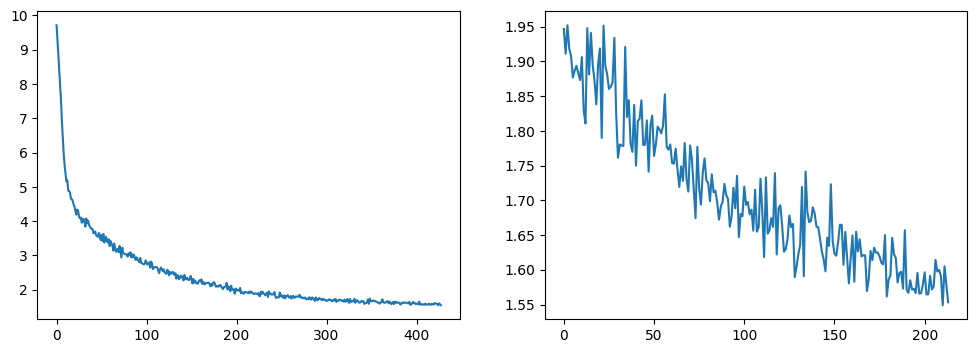

In [14]:
try:
    if train_language_model:
        loss = cobalt.language_model.trainer.loss
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].plot(loss['train.batch'])
        axs[1].plot(loss['train.batch'][int(0.5 * len(loss['train.batch'])):])
        plt.show()
except:
    traceback.print_exc()

In [15]:
try:
    if train_language_model:
        rewrite_language_model_cache = True
        if rewrite_language_model_cache:
            flight = 'Cobalt._prepare_language_model.cached'
            for file in ['bone', 'pkl']:
                file = os.path.join('temp', f'{flight}.{file}')
                if os.path.exists(file): os.remove(file)
            core.key_cached('cached', lambda: cobalt.language_model, group='Cobalt._prepare_language_model')
            print("Saved")
except:
    traceback.print_exc()

Saved


In [8]:
try:
    print(cobalt.inference('rock', ['black', 'enter', 'spell', 'priests', 'dragon'], max_len=400).replace(' <NEW_LINE> ', '\n'))
except:
    traceback.print_exc()

C:\Beryllium Base\WORKSPACES\MTECH\dl-gen-lyrics\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  result = _VF.gru(


<genre_rock> <theme_black> <theme_enter> <theme_spell> <theme_priests> <theme_dragon> <SONG_START> the you she she shess> , <NE>_LINE> she she she gone -
and
in in in life be be , love love love love love love , you , you i i
of for to the . . ? you you like like you you' : it
i i got got the the , " t'> when
you you "' the the
and andst to toed you like with ,s
, you you the the you you's ,
i to to <NEW_LINE>> ,
like like like a , and "
i i i i you see the , is , ,
" , i )s , ,NE> ,
, your your your on of
i i'tt
it like we'ss''t a a . , "" she more more . . , you i i i't like like , , ,ss
<NEW_LINE> and i i be be , me
your and i me let , , to to on on on
to ,
all a <NE> 
